# HW2 — Diferencias Finitas y Métodos Numéricos
## Matemáticas Avanzadas — Prof. Enrique Pereira

**Autor:** Jesus Antonio Martinez Velandia  
**Asignatura:** MATEMATICAS AVANZADAS PARA INGENIERIA-1048-202650  
**Fecha:** Febrero 2026

---

### Estructura del notebook

| Sección | Contenido |
|---------|-----------|
| 1 | Problema 1 — Aproximación de $\cos(0.2)$ con Taylor de 4to orden |
| 2 | Problema 2(a) — Derivación de fórmulas de diferencias finitas |
| 3 | Problema 2(b) — Error $O(h^2)$ de la diferencia central |
| 4 | Problema 2(c) — Derivada numérica de $\cos(x)$, error vs $h$ |
| 5 | Problema 2(d) — Exactitud de diferencia central para $f(x)=x^2$ |

> **Restricción del curso:** sólo `numpy`, `matplotlib` y `math.factorial`.  
> No se usa `scipy`, `sympy` ni `np.gradient`.

---
## Sección 0 — Imports y configuración global

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

# Estilo global
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

AZUL    = '#1f77b4'
ROJO    = '#d62728'
VERDE   = '#2ca02c'
NARANJA = '#ff7f0e'
MORADO  = '#9467bd'

print('Librerias cargadas correctamente.')
print(f'  numpy {np.__version__}')

Librerias cargadas correctamente.
  numpy 2.2.6


---
## Sección 1 — Problema 1: Aproximación de $\cos(0.2)$ con Taylor de 4to orden

### Enunciado
Aproximar $\cos(0.2)$ acumulando términos del polinomio de Taylor hasta orden 4.  
En cada orden calcular el error exacto $|f_n - \cos(0.2)|$ y la cota del error
de truncamiento. Hacer gráfica comparativa.

### Marco teórico

$$\cos(x) = \sum_{n=0}^{\infty} \frac{f^{(n)}(0)}{n!}\,x^n
= 1 - \frac{x^2}{2!} + \frac{x^4}{4!} - \cdots$$

| $k$ | $f^{(k)}(x)$ | $f^{(k)}(0)$ | $k!$ | Término |
|:---:|:---:|:---:|:---:|:---:|
| 0 | $\cos(x)$ | $1$ | $1$ | $1$ |
| 1 | $-\sin(x)$ | $0$ | $1$ | $0$ |
| 2 | $-\cos(x)$ | $-1$ | $2$ | $-x^2/2$ |
| 3 | $\sin(x)$ | $0$ | $6$ | $0$ |
| 4 | $\cos(x)$ | $1$ | $24$ | $x^4/24$ |

**Cota del Teorema del Resto:** como $|\cos^{(n+1)}(z)| \le 1$, se tiene $M=1$:
$$|E_n(0.2)| \le \frac{(0.2)^{n+1}}{(n+1)!}$$

In [4]:
# Problema 1: Taylor acumulado de cos(0.2)
x = 0.2
exacto = np.cos(x)

# Derivadas de cos(x) en a=0: patron ciclico [1, 0, -1, 0, 1]
derivadas_en_0 = [1, 0, -1, 0, 1]

aproximacion    = 0.0
errores_exactos = []
cotas_error     = []
ordenes         = list(range(5))

print('Orden | Aproximacion f_n   | Error exacto  | Cota |E_n|')
print('-' * 62)
for n in range(5):
    aproximacion += derivadas_en_0[n] * (x**n) / factorial(n)
    error_exacto  = abs(aproximacion - exacto)
    M    = 1
    cota = M * abs(x)**(n+1) / factorial(n+1)
    errores_exactos.append(error_exacto)
    cotas_error.append(cota)
    print(f'  {n}   | {aproximacion:.10f}   | {error_exacto:.4e}    | {cota:.4e}')

print(f'\nValor exacto  cos(0.2) = {exacto:.12f}')
print(f'Aproximacion  f_4       = {aproximacion:.12f}')

Orden | Aproximacion f_n   | Error exacto  | Cota |E_n|
--------------------------------------------------------------
  0   | 1.0000000000   | 1.9933e-02    | 2.0000e-01
  1   | 1.0000000000   | 1.9933e-02    | 2.0000e-02
  2   | 0.9800000000   | 6.6578e-05    | 1.3333e-03
  3   | 0.9800000000   | 6.6578e-05    | 6.6667e-05
  4   | 0.9800666667   | 8.8825e-08    | 2.6667e-06

Valor exacto  cos(0.2) = 0.980066577841
Aproximacion  f_4       = 0.980066666667


### Gráfica — Error exacto vs Cota de truncamiento

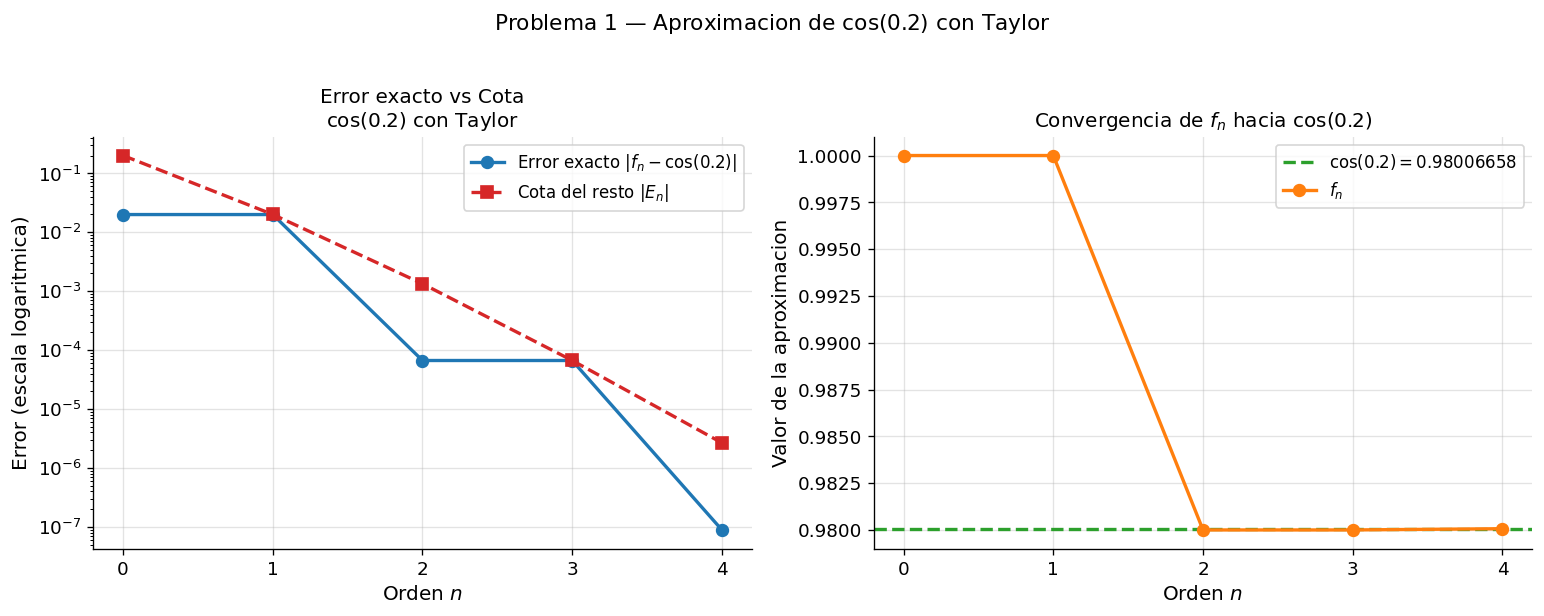

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: errores en escala log
axes[0].semilogy(ordenes, errores_exactos, 'o-', color=AZUL, lw=2, ms=7,
                 label='Error exacto $|f_n - \\cos(0.2)|$')
axes[0].semilogy(ordenes, cotas_error, 's--', color=ROJO, lw=2, ms=7,
                 label='Cota del resto $|E_n|$')
axes[0].set_xlabel('Orden $n$', fontsize=12)
axes[0].set_ylabel('Error (escala logaritmica)', fontsize=12)
axes[0].set_title('Error exacto vs Cota\n$\\cos(0.2)$ con Taylor', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_xticks(ordenes)

# Panel derecho: convergencia del valor aproximado
axes[1].axhline(exacto, color=VERDE, lw=2, linestyle='--',
                label=f'$\\cos(0.2) = {exacto:.8f}$')
a, aprox_acum = 0.0, []
for n in range(5):
    a += derivadas_en_0[n] * (x**n) / factorial(n)
    aprox_acum.append(a)
axes[1].plot(ordenes, aprox_acum, 'o-', color=NARANJA, lw=2, ms=7, label='$f_n$')
axes[1].set_xlabel('Orden $n$', fontsize=12)
axes[1].set_ylabel('Valor de la aproximacion', fontsize=12)
axes[1].set_title('Convergencia de $f_n$ hacia $\\cos(0.2)$', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].set_xticks(ordenes)

fig.suptitle('Problema 1 — Aproximacion de $\\cos(0.2)$ con Taylor', fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig('diferencias_finitas_graficas/prob1_taylor_cos.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 2 — Problema 2(a): Derivación de fórmulas de diferencias finitas

### Enunciado

**(i)** $\displaystyle f''(x_j) = \frac{-f(x_{j+3})+4f(x_{j+2})-5f(x_{j+1})+2f(x_j)}{h^2} + O(h^2)$

**(ii)** $\displaystyle f'''(x_j) = \frac{f(x_{j+3})-3f(x_{j+2})+3f(x_{j+1})-f(x_j)}{h^3} + O(h)$

---

### Expansiones de Taylor

$$f(x_j+h)  = f_j + hf' + \tfrac{h^2}{2}f'' + \tfrac{h^3}{6}f''' + \tfrac{h^4}{24}f'''' + O(h^5) \quad(A)$$
$$f(x_j+2h) = f_j + 2hf' + \tfrac{4h^2}{2}f'' + \tfrac{8h^3}{6}f''' + \tfrac{16h^4}{24}f'''' + O(h^5) \quad(B)$$
$$f(x_j+3h) = f_j + 3hf' + \tfrac{9h^2}{2}f'' + \tfrac{27h^3}{6}f''' + \tfrac{81h^4}{24}f'''' + O(h^5) \quad(C)$$

### Parte (i) — combinación $-C+4B-5A+2f_j$

| Término | Coeficientes | Resultado |
|---------|-------------|-----------|
| $f_j$ | $-1+4-5+2$ | $= 0$ ✓ |
| $hf'$ | $-3+8-5$ | $= 0$ ✓ |
| $h^2f''/2$ | $-9+16-5$ | $= 2$ → da $h^2f''$ ✓ |
| $h^3f'''/6$ | $-27+32-5$ | $= 0$ ✓ |
| $h^4f''''/24$ | $-81+64-5$ | $= -22$ → residuo $O(h^2)$ al dividir por $h^2$ |

### Parte (ii) — combinación $C-3B+3A-f_j$

| Término | Coeficientes | Resultado |
|---------|-------------|-----------|
| $f_j$ | $1-3+3-1$ | $= 0$ ✓ |
| $hf'$ | $3-6+3$ | $= 0$ ✓ |
| $h^2f''/2$ | $9-12+3$ | $= 0$ ✓ |
| $h^3f'''/6$ | $27-24+3$ | $= 6$ → da $h^3f'''$ ✓ |
| $h^4f''''/24$ | $81-48+3$ | $= 36$ → residuo $O(h)$ al dividir por $h^3$ |

### Verificación numérica en $x_0 = 1$, $h = 0.1$

In [6]:
# Problema 2(a): verificacion en un punto
# f(x) = cos(x)  =>  f''(x) = -cos(x),  f'''(x) = sin(x)

x0 = 1.0
h  = 0.1

fj  = np.cos(x0)
fj1 = np.cos(x0 +   h)
fj2 = np.cos(x0 + 2*h)
fj3 = np.cos(x0 + 3*h)

# (i) Segunda derivada forward O(h^2)
f2_num = (-fj3 + 4*fj2 - 5*fj1 + 2*fj) / h**2
f2_ex  = -np.cos(x0)

# (ii) Tercera derivada forward O(h)
f3_num = (fj3 - 3*fj2 + 3*fj1 - fj) / h**3
f3_ex  =  np.sin(x0)

print('=' * 50)
print(f'  Segunda derivada forward O(h^2) -- h = {h}')
print('=' * 50)
print(f'  Numerica  f_2({x0}) = {f2_num:.10f}')
print(f'  Exacta    f_2({x0}) = {f2_ex:.10f}')
print(f'  Error             = {abs(f2_num - f2_ex):.4e}')
print()
print('=' * 50)
print(f'  Tercera derivada forward O(h)  -- h = {h}')
print('=' * 50)
print(f'  Numerica  f_3({x0}) = {f3_num:.10f}')
print(f'  Exacta    f_3({x0}) = {f3_ex:.10f}')
print(f'  Error             = {abs(f3_num - f3_ex):.4e}')

  Segunda derivada forward O(h^2) -- h = 0.1
  Numerica  f_2(1.0) = -0.5443806110
  Exacta    f_2(1.0) = -0.5403023059
  Error             = 4.0783e-03

  Tercera derivada forward O(h)  -- h = 0.1
  Numerica  f_3(1.0) = 0.9116236032
  Exacta    f_3(1.0) = 0.8414709848
  Error             = 7.0153e-02


### Convergencia de errores con $h$ decreciente

In [7]:
# Tabla de convergencia para demostrar O(h^2) y O(h)
h_vals_a = [0.5, 0.2, 0.1, 0.05, 0.01, 0.005, 0.001]
errs_f2, errs_f3 = [], []

print('h        | Error f2   | Error/h2  | Error f3   | Error/h')
print('-' * 62)
for h in h_vals_a:
    fj0  = np.cos(x0)
    fj1t = np.cos(x0 +   h)
    fj2t = np.cos(x0 + 2*h)
    fj3t = np.cos(x0 + 3*h)
    e2 = abs((-fj3t + 4*fj2t - 5*fj1t + 2*fj0) / h**2 - (-np.cos(x0)))
    e3 = abs(( fj3t - 3*fj2t + 3*fj1t -   fj0) / h**3 -   np.sin(x0))
    errs_f2.append(e2)
    errs_f3.append(e3)
    print(f'{h:.4f}  | {e2:.4e} | {e2/h**2:.6f} | {e3:.4e}  | {e3/h:.6f}')

print()
print('Error/h2 aprox constante => O(h^2) confirmado para f_2')
print('Error/h  aprox constante => O(h)  confirmado para f_3')

h        | Error f2   | Error/h2  | Error f3   | Error/h
--------------------------------------------------------------
0.5000  | 5.7982e-03 | 0.023193 | 1.1218e-01  | 0.224357
0.2000  | 1.2599e-02 | 0.314984 | 1.1728e-01  | 0.586399
0.1000  | 4.0783e-03 | 0.407831 | 7.0153e-02  | 0.701526
0.0500  | 1.1309e-03 | 0.452342 | 3.7844e-02  | 0.756887
0.0100  | 4.8683e-05 | 0.486827 | 7.9989e-03  | 0.799895
0.0050  | 1.2277e-05 | 0.491062 | 4.0259e-03  | 0.805184
0.0010  | 4.9485e-07 | 0.494854 | 8.0970e-04  | 0.809705

Error/h2 aprox constante => O(h^2) confirmado para f_2
Error/h  aprox constante => O(h)  confirmado para f_3


### Gráfica log-log de convergencia

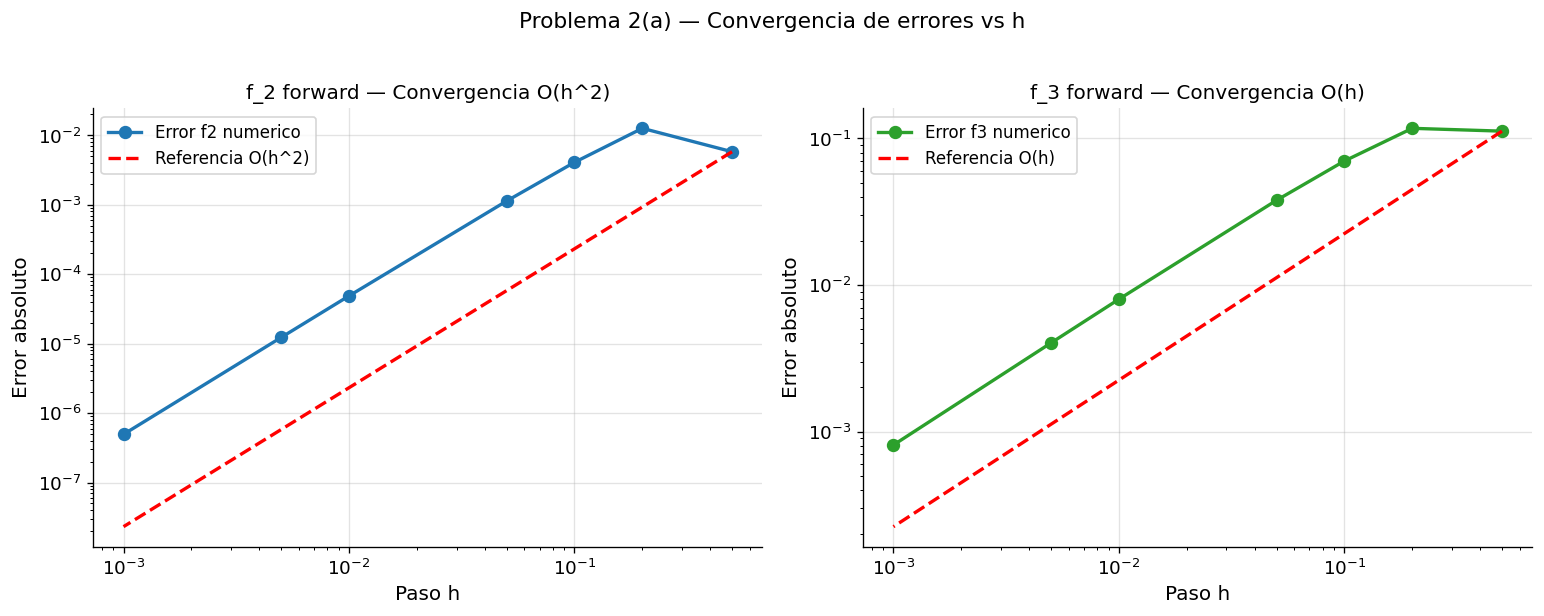

In [8]:
h_plot_a = np.array(h_vals_a)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: f'' O(h^2)
axes[0].loglog(h_plot_a, errs_f2, 'o-', color=AZUL, lw=2, ms=7,
               label='Error f2 numerico')
axes[0].loglog(h_plot_a, h_plot_a**2 * errs_f2[0]/h_plot_a[0]**2, 'r--', lw=2,
               label='Referencia O(h^2)')
axes[0].set_xlabel('Paso h', fontsize=12)
axes[0].set_ylabel('Error absoluto', fontsize=12)
axes[0].set_title('f_2 forward — Convergencia O(h^2)', fontsize=12)
axes[0].legend(fontsize=10)

# Panel derecho: f''' O(h)
axes[1].loglog(h_plot_a, errs_f3, 'o-', color=VERDE, lw=2, ms=7,
               label='Error f3 numerico')
axes[1].loglog(h_plot_a, h_plot_a * errs_f3[0]/h_plot_a[0], 'r--', lw=2,
               label='Referencia O(h)')
axes[1].set_xlabel('Paso h', fontsize=12)
axes[1].set_ylabel('Error absoluto', fontsize=12)
axes[1].set_title('f_3 forward — Convergencia O(h)', fontsize=12)
axes[1].legend(fontsize=10)

fig.suptitle('Problema 2(a) — Convergencia de errores vs h', fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig('diferencias_finitas_graficas/prob2a_convergencia.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 3 — Problema 2(b): Error $O(h^2)$ de la diferencia central

### Enunciado
Demostrar que $\displaystyle f'(x_j) \approx \frac{f(x_{j+1})-f(x_{j-1})}{2h}$
tiene error de truncamiento $O(h^2)$.

### Demostración analítica

$$f(x_j+h) = f_j + hf' + \tfrac{h^2}{2}f'' + \tfrac{h^3}{6}f''' + \tfrac{h^4}{24}f'''' + O(h^5) \quad(A)$$
$$f(x_j-h) = f_j - hf' + \tfrac{h^2}{2}f'' - \tfrac{h^3}{6}f''' + \tfrac{h^4}{24}f'''' + O(h^5) \quad(B)$$

**Restar $A - B$ término a término:**

| Par de términos | Resultado |
|-----------------|-----------|
| $f_j - f_j$ | $= 0$ ✓ |
| $hf' - (-hf')$ | $= 2hf'$ |
| $\frac{h^2}{2}f'' - \frac{h^2}{2}f''$ | $= 0$ ✓ (pares se cancelan) |
| $\frac{h^3}{6}f''' + \frac{h^3}{6}f'''$ | $= \frac{h^3}{3}f'''$ |
| $\frac{h^4}{24}f'''' - \frac{h^4}{24}f''''$ | $= 0$ ✓ |

$$f(x_j+h)-f(x_j-h) = 2hf' + \frac{h^3}{3}f''' + O(h^5)$$

Dividiendo por $2h$:
$$\boxed{f'(x_j) = \frac{f(x_{j+1})-f(x_{j-1})}{2h} - \frac{h^2}{6}f'''(x_j) + O(h^4) = O(h^2)}$$

### Verificación numérica del orden $O(h^2)$

In [9]:
# Problema 2(b): orden O(h^2) diferencia central
# f(x) = cos(x),  f'(x) = -sin(x),  f'''(x) = sin(x)

x0 = 1.0
exacta_derivada = -np.sin(x0)

h_vals_b  = [0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0001]
errors_cd = []
ratios    = []

print('Verificacion del orden O(h^2) — Diferencia Central')
print('h         | Aprox derivada  | Error      | Error/h2')
print('-' * 58)
for h in h_vals_b:
    aprox = (np.cos(x0 + h) - np.cos(x0 - h)) / (2*h)
    err   = abs(aprox - exacta_derivada)
    ratio = err / h**2
    errors_cd.append(err)
    ratios.append(ratio)
    print(f'{h:.5f}   | {aprox:.12f} | {err:.4e} | {ratio:.6f}')

print(f'\nDerivada exacta -sin({x0}) = {exacta_derivada:.12f}')
print(f'Prediccion teorica sin({x0})/6 = {np.sin(x0)/6:.6f}')
print('Error/h2 aprox constante confirma O(h^2)')

Verificacion del orden O(h^2) — Diferencia Central
h         | Aprox derivada  | Error      | Error/h2
----------------------------------------------------------
0.50000   | -0.806845360223 | 3.4626e-02 | 0.138502
0.10000   | -0.840069234225 | 1.4018e-03 | 0.140175
0.05000   | -0.841120415722 | 3.5057e-04 | 0.140228
0.01000   | -0.841456960362 | 1.4024e-05 | 0.140244
0.00500   | -0.841467478683 | 3.5061e-06 | 0.140245
0.00100   | -0.841470844563 | 1.4025e-07 | 0.140245
0.00010   | -0.841470983405 | 1.4025e-09 | 0.140253

Derivada exacta -sin(1.0) = -0.841470984808
Prediccion teorica sin(1.0)/6 = 0.140245
Error/h2 aprox constante confirma O(h^2)


### Gráfica — Error log-log y ratio $\text{Error}/h^2$

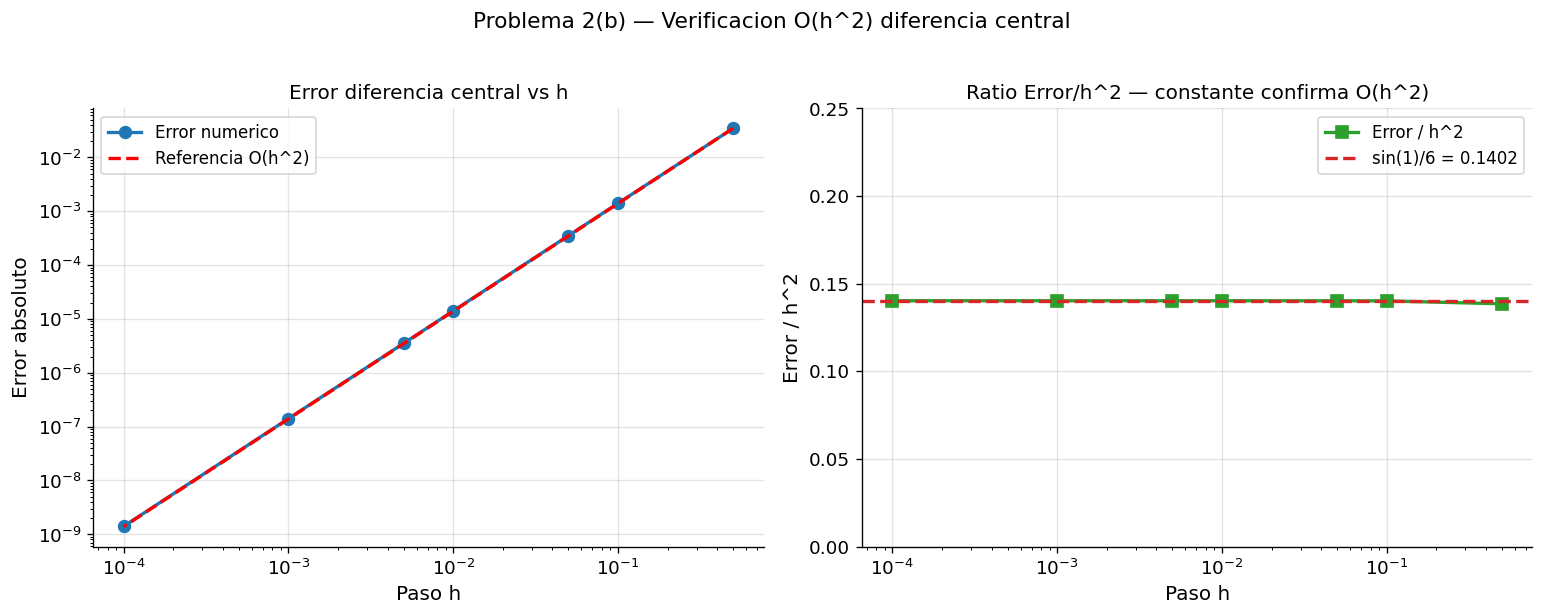

In [10]:
h_arr_b = np.array(h_vals_b)
err_arr = np.array(errors_cd)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: error en escala log-log
axes[0].loglog(h_arr_b, err_arr, 'o-', color=AZUL, lw=2, ms=7,
               label='Error numerico')
axes[0].loglog(h_arr_b, h_arr_b**2 * err_arr[0]/h_arr_b[0]**2, 'r--', lw=2,
               label='Referencia O(h^2)')
axes[0].set_xlabel('Paso h', fontsize=12)
axes[0].set_ylabel('Error absoluto', fontsize=12)
axes[0].set_title('Error diferencia central vs h', fontsize=12)
axes[0].legend(fontsize=10)

# Panel derecho: ratio Error/h^2 debe ser constante
axes[1].semilogx(h_arr_b, ratios, 's-', color=VERDE, lw=2, ms=7,
                 label='Error / h^2')
pred = np.sin(x0) / 6
axes[1].axhline(pred, color=ROJO, lw=2, linestyle='--',
                label=f'sin(1)/6 = {pred:.4f}')
axes[1].set_xlabel('Paso h', fontsize=12)
axes[1].set_ylabel('Error / h^2', fontsize=12)
axes[1].set_title('Ratio Error/h^2 — constante confirma O(h^2)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 0.25)

fig.suptitle('Problema 2(b) — Verificacion O(h^2) diferencia central', fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig('diferencias_finitas_graficas/prob2b_orden_h2.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 4 — Problema 2(c): Error máximo vs $h$ para la derivada de $\cos(x)$

### Enunciado
Aproximar $\frac{d}{dx}\cos(x) = -\sin(x)$ con diferencia central sobre
$x \in [0, 2\pi]$ para múltiples valores de $h$.  
Graficar el error máximo en escala log-log y comparar con $O(h^2)$.

### Comportamiento esperado

- **Rango $h \in [10^{-4}, 1]$:** pendiente $2$ en log-log → $O(h^2)$.
- **Rango $h < 10^{-7}$:** error **aumenta** por cancelación catastrófica en punto flotante.
- **Predicción teórica:** $E_{\max}(h) \approx h^2/6$ ya que $\max|\sin x| = 1$.

In [11]:
# Problema 2(c): error maximo vs h para cos(x)
x_grid = np.linspace(0, 2*np.pi, 1000)
exacta  = -np.sin(x_grid)

h_values_c = np.logspace(-8, 0, 80)
max_errors = []

for h in h_values_c:
    derivada_aprox = (np.cos(x_grid + h) - np.cos(x_grid - h)) / (2*h)
    max_errors.append(np.max(np.abs(derivada_aprox - exacta)))

max_errors = np.array(max_errors)

print('{:>12} | {:>14} | {:>12}'.format('h', 'Error maximo', 'E/h2'))
print('-' * 44)
for h, e in list(zip(h_values_c, max_errors))[::10]:
    print(f'{h:>12.2e} | {e:>14.2e} | {e/h**2:>12.4f}')

           h |   Error maximo |         E/h2
--------------------------------------------
    1.00e-08 |       9.24e-09 | 92391166.9393
    1.03e-07 |       4.12e-09 |  388604.4969
    1.06e-06 |       3.66e-10 |     325.3671
    1.09e-05 |       2.64e-11 |       0.2217
    1.12e-04 |       2.10e-09 |       0.1666
    1.16e-03 |       2.23e-07 |       0.1667
    1.19e-02 |       2.36e-05 |       0.1667
    1.23e-01 |       2.50e-03 |       0.1665


### Gráfica log-log

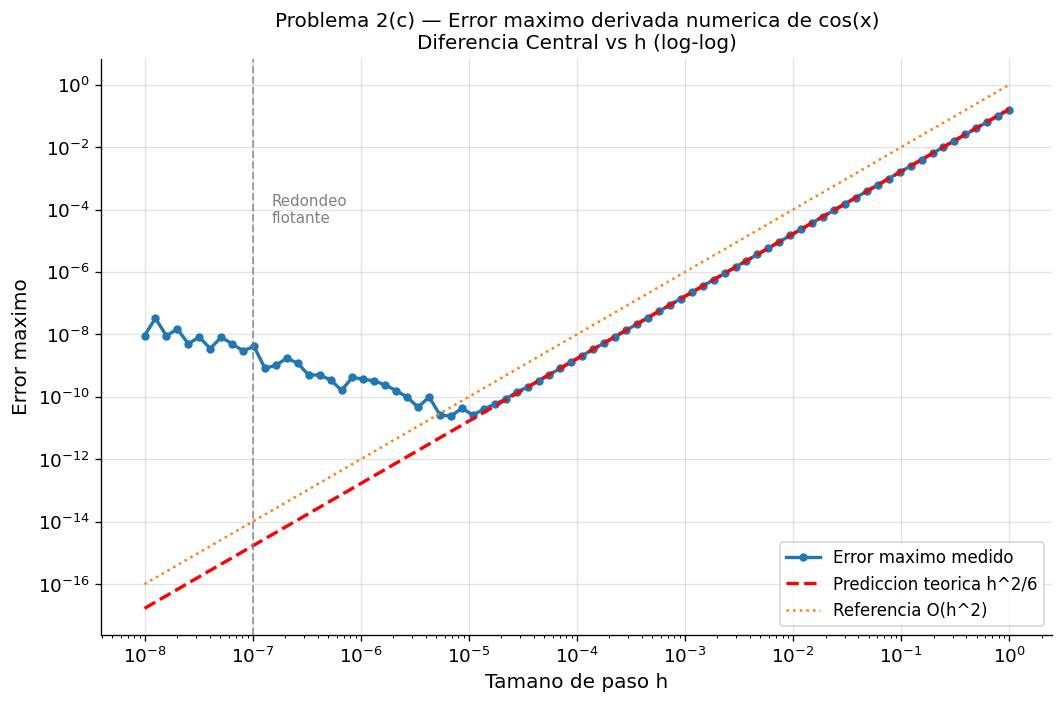

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.loglog(h_values_c, max_errors, 'o-', color=AZUL, lw=2, ms=4,
          label='Error maximo medido')
ax.loglog(h_values_c, h_values_c**2 / 6, 'r--', lw=2,
          label='Prediccion teorica h^2/6')
ax.loglog(h_values_c, h_values_c**2, ':', color=NARANJA, lw=1.5,
          label='Referencia O(h^2)')

ax.axvline(1e-7, color='gray', lw=1.2, linestyle='--', alpha=0.7)
ax.text(1.5e-7, 1e-4, 'Redondeo\nflotante', fontsize=9, color='gray',
        ha='left', va='center')

ax.set_xlabel('Tamano de paso h', fontsize=12)
ax.set_ylabel('Error maximo', fontsize=12)
ax.set_title('Problema 2(c) — Error maximo derivada numerica de cos(x)\n'
             'Diferencia Central vs h (log-log)', fontsize=12)
ax.legend(fontsize=10)
fig.tight_layout()
plt.savefig('diferencias_finitas_graficas/prob2c_error_vs_h.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 5 — Problema 2(d): Diferencia central exacta para $f(x) = x^2$

### Enunciado
Demostrar que la diferencia central produce la derivada **exacta** de $f(x) = x^2$
para cualquier $h > 0$.

### Demostración analítica

**Paso 1 — Calcular $f(x_0 \pm h)$:**
$$f(x_0+h) = (x_0+h)^2 = x_0^2 + 2x_0 h + h^2$$
$$f(x_0-h) = (x_0-h)^2 = x_0^2 - 2x_0 h + h^2$$

**Paso 2 — Diferencia:**
$$f(x_0+h)-f(x_0-h) = 4x_0 h$$

**Paso 3 — Aplicar fórmula:**
$$\frac{f(x_0+h)-f(x_0-h)}{2h} = \frac{4x_0 h}{2h} = 2x_0$$

**Paso 4 — Comparar con derivada exacta:**
$$f'(x_0) = 2x_0 \quad\Rightarrow\quad \text{Error} = 0 \quad\forall\, h$$

> **¿Por qué?** $E = -\frac{h^2}{6}f'''(x_0)$ y para $f(x)=x^2$: $f'''=0$ → $E=0$ ✓

In [13]:
# Problema 2(d): diferencia central exacta para f(x) = x^2
f       = lambda x: x**2
f_prima = lambda x: 2*x

x0_values  = np.linspace(0, 4, 200)
h_values_d = [0.5, 0.3, 0.2, 0.1, 0.05, 0.01, 0.001]

print('Verificacion: error diferencia central para f(x) = x^2')
print('h        | Error maximo en [0, 4]')
print('-' * 35)
for h in h_values_d:
    aprox = (f(x0_values + h) - f(x0_values - h)) / (2*h)
    error = np.max(np.abs(aprox - f_prima(x0_values)))
    print(f'{h:.4f}   | {error:.4e}')

print('\nError ~ 0 (maquina) para todo h => EXACTA para polinomios grado <= 2')

Verificacion: error diferencia central para f(x) = x^2
h        | Error maximo en [0, 4]
-----------------------------------
0.5000   | 6.2172e-15
0.3000   | 7.9936e-15
0.2000   | 9.7700e-15
0.1000   | 1.5099e-14
0.0500   | 4.0856e-14
0.0100   | 2.2649e-13
0.0010   | 1.7835e-12

Error ~ 0 (maquina) para todo h => EXACTA para polinomios grado <= 2


### Gráfica — varias $h$ superpuestas y error vs $h$

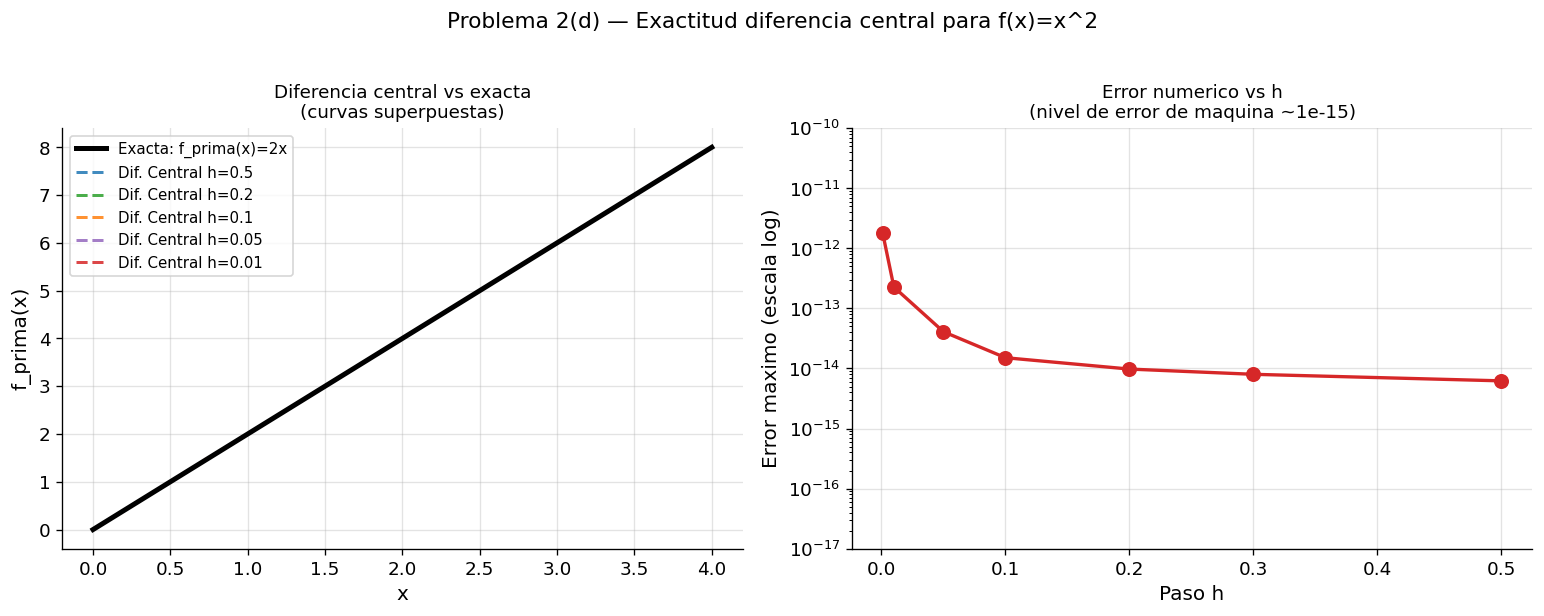

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: exacta vs numerica para varias h
exacta_plot = f_prima(x0_values)
colores_h   = [AZUL, VERDE, NARANJA, MORADO, ROJO]
axes[0].plot(x0_values, exacta_plot, 'k-', lw=3,
             label='Exacta: f_prima(x)=2x', zorder=5)
for i, h in enumerate([0.5, 0.2, 0.1, 0.05, 0.01]):
    aprox_h = (f(x0_values + h) - f(x0_values - h)) / (2*h)
    axes[0].plot(x0_values, aprox_h, '--', color=colores_h[i],
                 lw=1.8, alpha=0.85, label=f'Dif. Central h={h}')
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('f_prima(x)', fontsize=12)
axes[0].set_title('Diferencia central vs exacta\n(curvas superpuestas)', fontsize=11)
axes[0].legend(fontsize=9, loc='upper left')

# Panel derecho: error por h (debe estar en nivel de maquina)
errors_d = []
for h in h_values_d:
    ap = (f(x0_values + h) - f(x0_values - h)) / (2*h)
    errors_d.append(np.max(np.abs(ap - f_prima(x0_values))))

axes[1].semilogy(h_values_d, errors_d, 'o-', color=ROJO, lw=2, ms=8)
axes[1].set_xlabel('Paso h', fontsize=12)
axes[1].set_ylabel('Error maximo (escala log)', fontsize=12)
axes[1].set_title('Error numerico vs h\n(nivel de error de maquina ~1e-15)', fontsize=11)
axes[1].set_ylim(1e-17, 1e-10)

fig.suptitle('Problema 2(d) — Exactitud diferencia central para f(x)=x^2',
             fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig('diferencias_finitas_graficas/prob2d_exactitud_x2.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Resumen de resultados

| Problema | Resultado principal | Orden / Error |
|----------|--------------------|--------------:|
| **1** | $\cos(0.2) \approx 0.9800\ 6667$ con Taylor orden 4 | $\|E_4\| \le 2.67\times10^{-7}$ |
| **2(a)(i)** | $f'' = (-f_{j+3}+4f_{j+2}-5f_{j+1}+2f_j)/h^2$ | $O(h^2)$ ✓ |
| **2(a)(ii)** | $f''' = (f_{j+3}-3f_{j+2}+3f_{j+1}-f_j)/h^3$ | $O(h)$ ✓ |
| **2(b)** | Error diferencia central $= -h^2 f'''/6$ | $O(h^2)$ ✓ |
| **2(c)** | Mínimo error en $h \approx 10^{-4}$; crece para $h < 10^{-7}$ | $O(h^2)$ en rango central |
| **2(d)** | Error $= 0$ para $f(x)=x^2$ para cualquier $h$ | Exacto ✓ |

**Archivos generados:**  
`prob1_taylor_cos.png` · `prob2a_convergencia.png` · `prob2b_orden_h2.png` · `prob2c_error_vs_h.png` · `prob2d_exactitud_x2.png`